In [1]:

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)


In [2]:
print("Loading processed data for Module 1 & 4 Analysis...\n")

# Load the preserved dataframes
df_cleaned = pd.read_pickle('../data/processed/df_cleaned.pkl')
X_train_scaled = pd.read_pickle('../data/processed/X_train_scaled.pkl')
y_train = pd.read_pickle('../data/processed/y_train.pkl')['price'] # Extract back as Series

print(f"Data Loaded Successfully!")
print(f"df_cleaned shape: {df_cleaned.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Loading processed data for Module 1 & 4 Analysis...

Data Loaded Successfully!
df_cleaned shape: (369015, 49)
X_train_scaled shape: (295212, 48)


In [3]:
df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 369015 entries, 27 to 426879
Data columns (total 49 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   price                    369015 non-null  int64  
 1   year                     369015 non-null  float32
 2   condition                369015 non-null  int8   
 3   cylinders                369015 non-null  int8   
 4   odometer                 369015 non-null  float32
 5   size                     369015 non-null  int8   
 6   manufacturer             369015 non-null  float32
 7   state                    369015 non-null  float32
 8   region                   369015 non-null  float32
 9   model                    369015 non-null  float32
 10  fuel_electric            369015 non-null  int8   
 11  fuel_gas                 369015 non-null  int8   
 12  fuel_hybrid              369015 non-null  int8   
 13  fuel_other               369015 non-null  int8   
 14  title_st

In [4]:
df_cleaned.head()


,price,year,condition,cylinders,odometer,size,manufacturer,state,region,model,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,transmission_manual,transmission_other,drive_fwd,drive_rwd,drive_unknown,paint_color_blue,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,paint_color_unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,type_unknown
27,33590,2014.0,3,8,57923.0,0,25267.568359,21187.634766,27818.490234,34840.000000,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
28,22590,2010.0,3,8,71229.0,0,20314.625000,21094.445312,27949.908203,24027.708984,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
29,39590,2020.0,3,8,19160.0,0,20382.128906,21440.855469,27982.000000,34136.683594,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
30,30990,2017.0,3,8,41124.0,0,17414.039062,21316.886719,27741.681641,34674.421875,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
31,15000,2013.0,4,6,128000.0,4,21269.656250,21187.634766,27818.490234,21970.345703,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [5]:
print("Starting Statistical Hypothesis Testing...\n")

# T-TEST: Gas vs Non-Gas Vehicle Prices
# Null Hypothesis (H0): Gas vehicles have the same price as non-gas vehicles.
# Filtering prices based on the dummy variable we created
gas_prices = df_cleaned[df_cleaned['fuel_gas'] == 1]['price']
other_prices = df_cleaned[df_cleaned['fuel_gas'] == 0]['price']

# Perform Independent T-Test
t_stat, p_value_t = stats.ttest_ind(gas_prices, other_prices, equal_var=False)

print("T-Test (Gas vs Other Fuels)")
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value_t:.4f}")
if p_value_t < 0.05:
    print("Result: Reject H0. There IS a significant difference in prices.\n")
else:
    print("Result: Accept H0. No significant difference.\n")


Starting Statistical Hypothesis Testing...

T-Test (Gas vs Other Fuels)
T-Statistic: -163.72
P-Value: 0.0000
Result: Reject H0. There IS a significant difference in prices.



In [6]:
# ANOVA (F-Test): Price across different conditions
# Null Hypothesis (H0): All conditions (0 to 6) have the same mean price.
# Group prices by condition
condition_groups = [group['price'].values for name, group in df_cleaned.groupby('condition')]

f_stat, p_value_f = stats.f_oneway(*condition_groups)

print("ANOVA Test (Prices across Conditions)")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value_f:.4f}")
if p_value_f < 0.05:
    print("Result: Reject H0. Condition significantly impacts the price.\n")
else:
    print("Result: Accept H0. Condition doesn't matter.\n")


ANOVA Test (Prices across Conditions)
F-Statistic: 2854.56
P-Value: 0.0000
Result: Reject H0. Condition significantly impacts the price.



In [7]:

# CHI-SQUARE TEST: Cylinders vs Size
# Null Hypothesis (H0): Cylinders and Size are completely independent.
# Create a contingency table
contingency_table = pd.crosstab(df_cleaned['cylinders'], df_cleaned['size'])

chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test (Cylinders vs Size)")
print(f"Chi-Square Stat: {chi2:.2f}")
print(f"P-Value: {p_value_chi:.4f}")
if p_value_chi < 0.05:
    print("Result: Reject H0. Cylinders and Size are DEPENDENT on each other.\n")
else:
    print("Result: Accept H0. They are independent.\n")


Chi-Square Test (Cylinders vs Size)
Chi-Square Stat: 113756.17
P-Value: 0.0000
Result: Reject H0. Cylinders and Size are DEPENDENT on each other.



In [8]:
print("Starting Diagnostics...\n")

# MULTICOLLINEARITY: Variance Inflation Factor (VIF)
print("Calculating VIF for Top Features (Values > 5 indicate high multicollinearity)...")
# Taking a subset of continuous numerical features to save computation time
vif_features = ['year', 'odometer', 'manufacturer', 'model']
X_vif = X_train_scaled[vif_features]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
# Calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

display(vif_data)


Starting Diagnostics...

Calculating VIF for Top Features (Values > 5 indicate high multicollinearity)...


,Feature,VIF
0,year,1.075848
1,odometer,1.045423
2,manufacturer,1.166171
3,model,1.215797



Plotting Residuals to check Homoscedasticity...


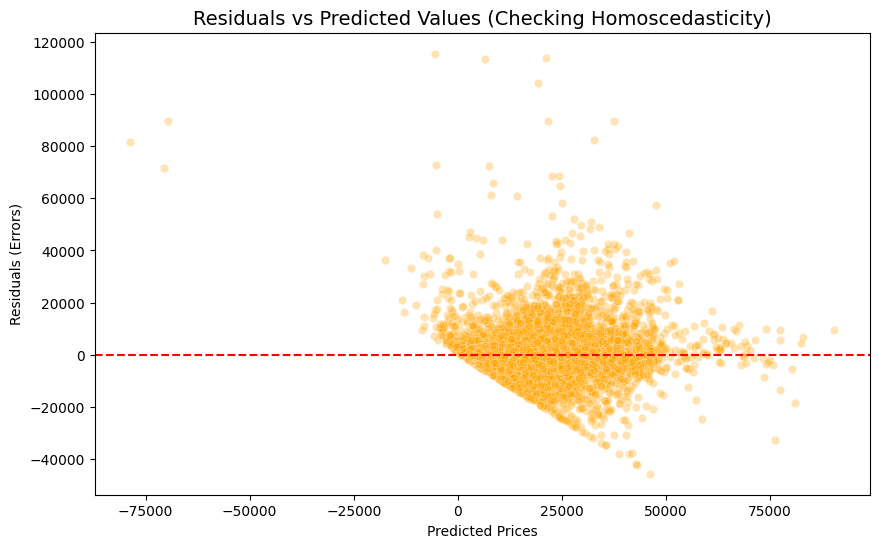

Observation:
If the dots form a random cloud around the red line -> Homoscedasticity (Good).
If the dots form a funnel/cone shape -> Heteroscedasticity (Bad for Linear Models).


In [9]:
# ASSUMPTIONS: Homoscedasticity Check (Residual Plot)
# We train a quick Linear Regression to get the residuals (errors)
print("\nPlotting Residuals to check Homoscedasticity...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_train = lr.predict(X_train_scaled)

# Calculate Residuals (Actual - Predicted)
residuals = y_train - y_pred_train

plt.figure(figsize=(10, 6))
# Plotting predicted values vs residuals. We take a sample to avoid memory crash
sns.scatterplot(x=y_pred_train[:10000], y=residuals[:10000], alpha=0.3, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values (Checking Homoscedasticity)', fontsize=14)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Errors)')
plt.show()

print("Observation:")
print("If the dots form a random cloud around the red line -> Homoscedasticity (Good).")
print("If the dots form a funnel/cone shape -> Heteroscedasticity (Bad for Linear Models).")
